### Step 1: Preparing the Notebook & Loading Data

In [21]:
# import statements

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage


In [2]:
# read the dataset
df = pd.read_csv("data/segmentation_data.csv")

In [3]:
# view the data and its structure
print(f"Shape: {df.shape}")
print("Column dtypes:")
print(df.dtypes)

Shape: (2000, 8)

Column dtypes:
ID                 int64
Sex                int64
Marital status     int64
Age                int64
Education          int64
Income             int64
Occupation         int64
Settlement size    int64
dtype: object


### Step 2: Data Preview & Cleanup

#### Data Preview

To start the data preview step, I created histograms to preview what the data looks like visually.

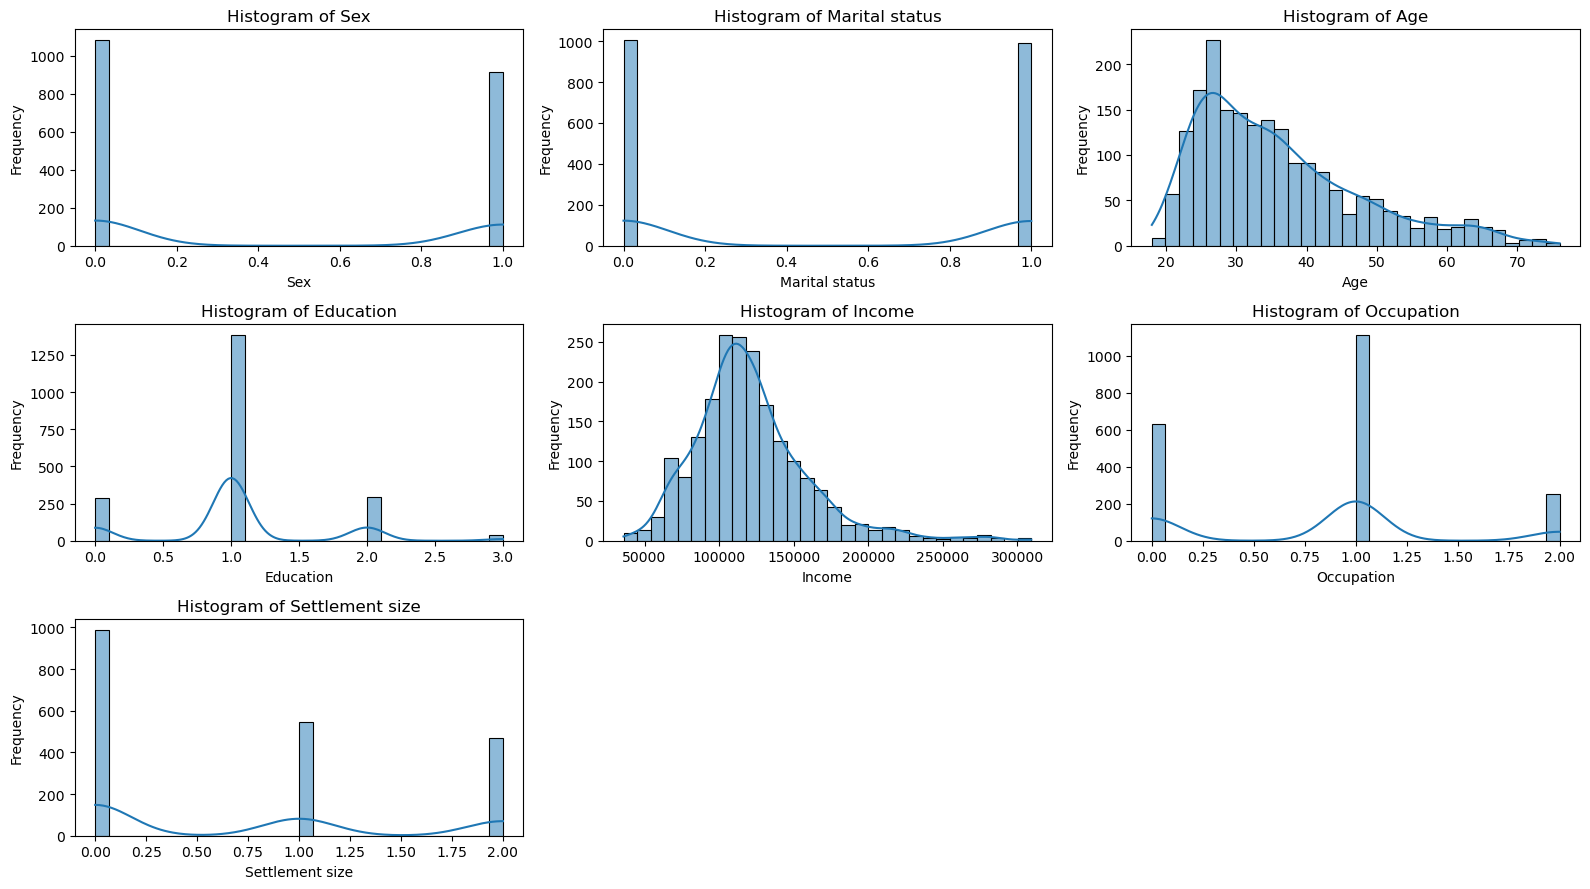

In [4]:
# Histograms for each feature
features = [col for col in df.columns
            if col not in ["ID"]]

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    sns.histplot(df[col], kde=True, bins=30, ax=ax)
    ax.set_title(f"Histogram of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<br>


#### Data Cleanup

In [5]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
ID                 0
Sex                0
Marital status     0
Age                0
Education          0
Income             0
Occupation         0
Settlement size    0
dtype: int64


In [6]:
df.head(10)

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1
5,100000006,0,0,35,1,144848,0,0
6,100000007,0,0,53,1,156495,1,1
7,100000008,0,0,35,1,193621,2,1
8,100000009,0,1,61,2,151591,0,0
9,100000010,0,1,28,1,174646,2,0


In [7]:
# function to remove unnecessary columns
def drop_columns(df, cols):
    df = df.drop(columns=cols)
    return df


df = drop_columns(df, ["ID"])
df.head()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1


In [8]:
# before outlier removal:
df.describe()

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [9]:
# after outlier removal
df_clean = df.copy()

for col in df_clean.select_dtypes(include=[np.number]).columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    before = len(df_clean)
    df_clean = df_clean[df_clean[col]
                        .between(lower, upper)].reset_index(drop=True)
    after = len(df_clean)

    print(f"{col}: removed {before - after} records that were outliers.")

print(f"Total rows after cleaning: {len(df_clean)}")

df_clean.describe()

Sex: removed 0 records that were outliers.
Marital status: removed 0 records that were outliers.
Age: removed 57 records that were outliers.
Education: removed 557 records that were outliers.
Income: removed 31 records that were outliers.
Occupation: removed 0 records that were outliers.
Settlement size: removed 0 records that were outliers.
Total rows after cleaning: 1355


,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,1355.000000,1355.000000,1355.000000,1355.0,1355.000000,1355.000000,1355.000000
mean,0.508487,0.557934,33.216236,1.0,114143.945387,0.776384,0.673801
std,0.500113,0.496816,8.334036,0.0,28399.360803,0.606004,0.792235
min,0.000000,0.000000,18.000000,1.0,38247.000000,0.000000,0.000000
25%,0.000000,0.000000,26.000000,1.0,95912.500000,0.000000,0.000000
50%,1.000000,1.000000,33.000000,1.0,111821.000000,1.000000,0.000000
75%,1.000000,1.000000,38.000000,1.0,129620.000000,1.000000,1.000000
max,1.000000,1.000000,58.000000,1.0,198029.000000,2.000000,2.000000


#### Data Cleanup Analysis

For data cleanup, there was no NULL records to remove. The reason for looking at the first 10 rows with head(10) was to determine if the records that hasv 0.00 were valid entries. These were either in Sex, Marital Status, or Education but having 0 for these values is jsutified because they were translated from boolean values.


As another step for cleanup, I dropped the outliers using 1.5 * IQR to drop records outside the IQR range.




###  Visualization of data cleanup

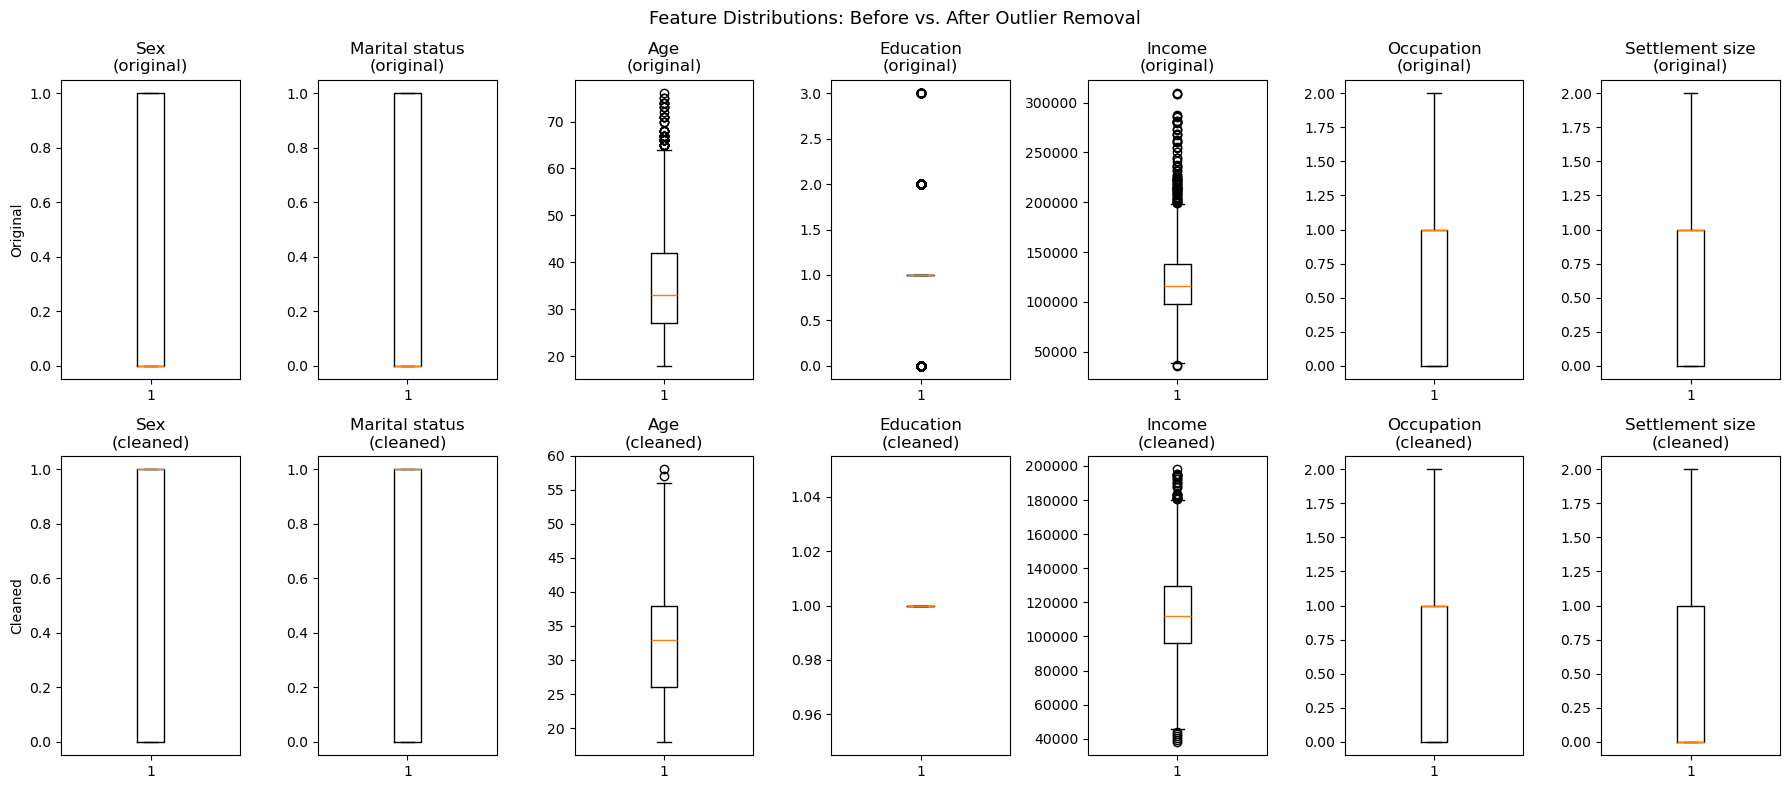

In [ ]:
def plot_distributions(df_original, df_clean):
    # Plot side-by-side boxplots for original vs. cleaned data
    features = df_original.columns.tolist()
    fig, axes = plt.subplots(2, len(features), figsize=(18, 8))

    for i, col in enumerate(features):
        axes[0, i].boxplot(df_original[col].dropna())
        axes[0, i].set_title(f"{col}\n(original)")
        axes[1, i].boxplot(df_clean[col].dropna())
        axes[1, i].set_title(f"{col}\n(cleaned)")

    axes[0, 0].set_ylabel("Original")
    axes[1, 0].set_ylabel("Cleaned")
    plt.suptitle(
        "Feature Distributions: Before vs. After Outlier Removal", fontsize=13
    )
    plt.tight_layout()
    plt.show()


plot_distributions(df, df_clean)

### Step 3: Feature Scaling

Standardize all numerical features using StandardScaler.



In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)
X = pd.DataFrame(X_scaled, columns=df_clean.columns)

print(f"Scaled shape: {X.shape}")
X.head()

Scaled shape: (1355, 7)


,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0.983167,0.890128,-1.346332,0.0,1.290261,0.369137,1.674615
1,-1.017121,-1.123434,1.894591,0.0,-0.878300,-1.281626,-0.850820
2,-1.017121,-1.123434,1.414454,0.0,2.022660,0.369137,0.411898
3,-1.017121,-1.123434,2.374728,0.0,1.228899,0.369137,0.411898
4,-1.017121,-1.123434,0.214113,0.0,1.081552,-1.281626,-0.850820


### Step 4: K Means Clsutering
Determining the optimal number of clusters

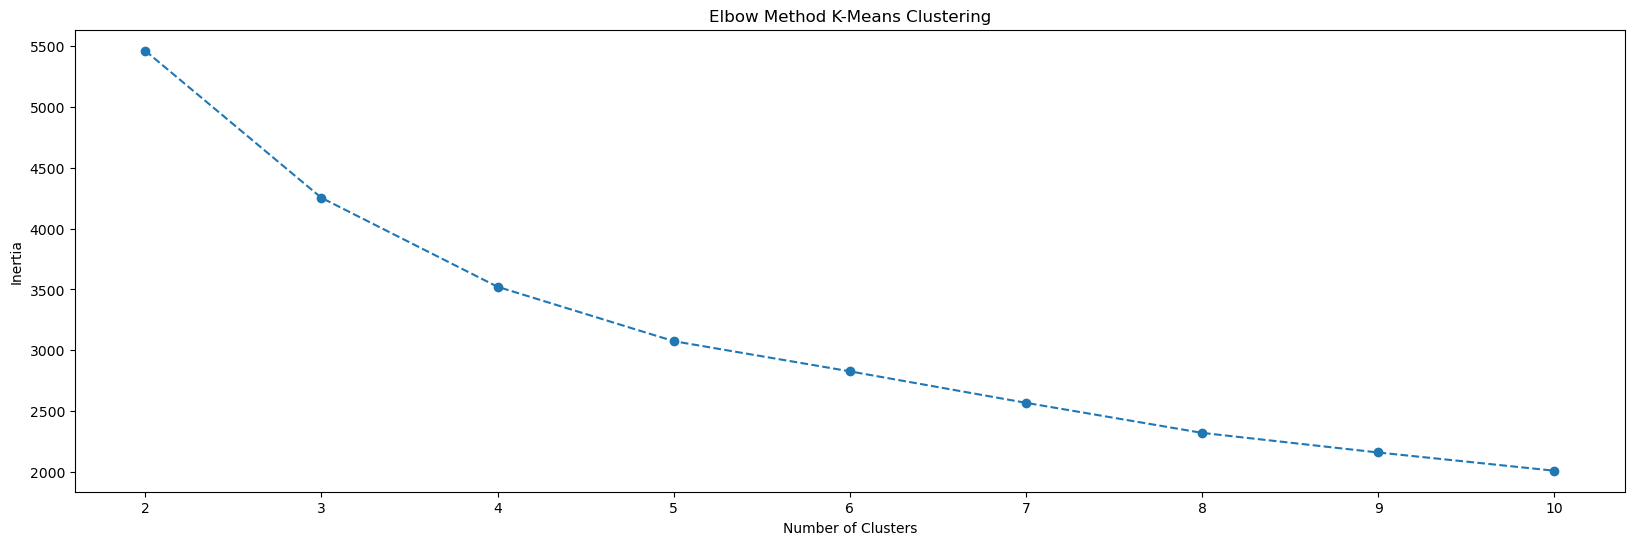

In [12]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k,
                    random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 6))
plt.plot(list(k_values), inertia, marker="o", linestyle="--")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method K-Means Clustering")
plt.show()

#### Analysis on Optimal K

To identify the optimal K value, we must plot inertia over K, and selet the point where the curve levels off. Based on the chart, I believe the curve starts leveling off where k = 4, and that is the optimal number of clusters.


### Step 5: Training a K Means Model.

In [13]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k,
                random_state=42, n_init=10)
df_clean["KMeans_Cluster"] = kmeans.fit_predict(X)

print("Cluster counts:")
print(df_clean["KMeans_Cluster"].value_counts().sort_index())

# Inverse transform centroids back to original feature space
centroids_original = scaler.inverse_transform(
    kmeans.cluster_centers_
)

Cluster counts:
KMeans_Cluster
0    527
1    403
2    425
Name: count, dtype: int64


### Step 6: Agglomerative Clustering

In [14]:
# Apply Agglomerative Clustering with same k as K-Means
agg = AgglomerativeClustering(n_clusters=optimal_k, linkage="ward")
df_clean["Agg_Cluster"] = agg.fit_predict(X)

### Step 7: Comparison of Agglomerative Clustering vs K-means
To do a comparison, I have created a scatterplot of steps 5 and 6 to visually compare them. 

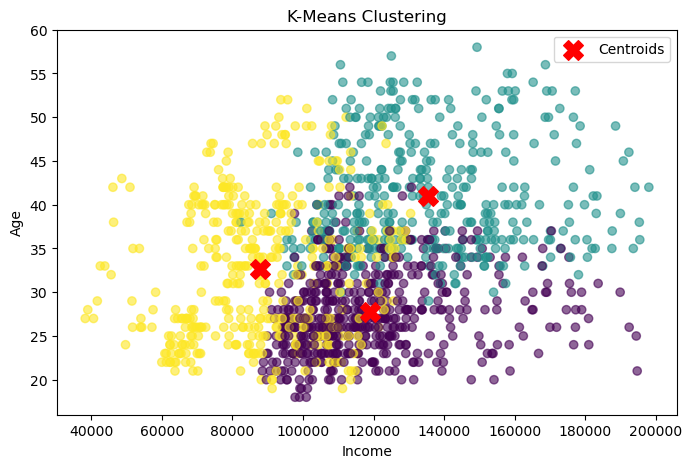

In [15]:
# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(
    df_clean["Income"],
    df_clean["Age"],
    c=df_clean["KMeans_Cluster"],
    cmap="viridis",
    alpha=0.6,
)
plt.scatter(
    centroids_original[:, 4],
    centroids_original[:, 2],  # 4 = Income, 2 = Age
    s=200,
    c="red",
    marker="X",
    label="Centroids",
)
plt.xlabel("Income")
plt.ylabel("Age")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

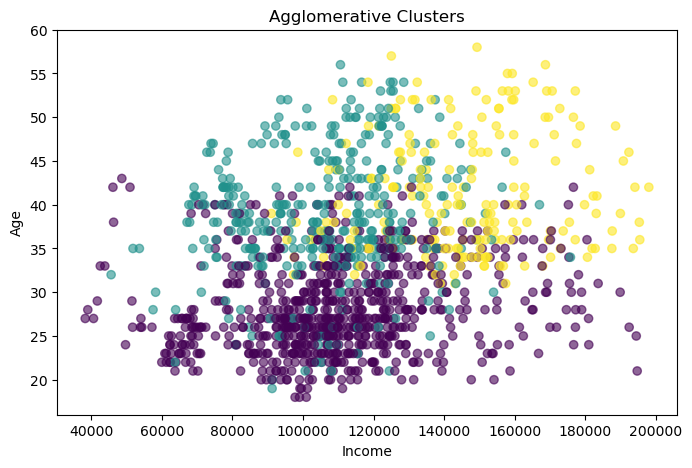

In [16]:
# Agglomerative scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(
    df_clean["Income"],
    df_clean["Age"],
    c=df_clean["Agg_Cluster"],
    cmap="viridis",
    alpha=0.6,
)
plt.title("Agglomerative Clusters")
plt.xlabel("Income")
plt.ylabel("Age")
plt.show()

### Analysis of Models:

Both the Agglormative and K means clustering show some distinction between people with lower vs higher credit limits. The models groups people with less than $20,000 credit limit and less than 4 credit cards nearly identical. Where the models seem to have differences with clustering is the distinction between low and high credit limit for the  group that have more than 4 credit cards. The difference between the distinction is not by much, but I think considering how much more data is in those groups it makes sense for a difference in bounds. 

#### Calculate silhouette scores and Davies-Bouldin scores for different k values.

In [17]:
sil_scores = []
db_scores = []
sil_scores_agg = []
db_scores_agg = []

for k in k_values:
    km_labels = KMeans(n_clusters=k,
                       random_state=42).fit_predict(X)
    agg_labels = AgglomerativeClustering(
        n_clusters=k, linkage="ward").fit_predict(X)

    sil_scores.append(silhouette_score(X, km_labels))
    db_scores.append(davies_bouldin_score(X, km_labels))
    sil_scores_agg.append(silhouette_score(X, agg_labels))
    db_scores_agg.append(davies_bouldin_score(X, agg_labels))

# Print results as a table
results_df = pd.DataFrame(
    {
        "k": list(k_values),
        "KMeans Silhouette": sil_scores,
        "Agg Silhouette": sil_scores_agg,
        "KMeans Davies-Bouldin": db_scores,
        "Agg Davies-Bouldin": db_scores_agg,
    }
)

results_df

,k,KMeans Silhouette,Agg Silhouette,KMeans Davies-Bouldin,Agg Davies-Bouldin
0,2,0.318562,0.302218,1.343005,1.444185
1,3,0.298033,0.270907,1.234189,1.319288
2,4,0.294834,0.235088,1.171977,1.224592
3,5,0.268294,0.267866,1.364429,1.388961
4,6,0.297216,0.291018,1.358491,1.371040
5,7,0.321549,0.309436,1.275900,1.278335
6,8,0.296917,0.307681,1.267070,1.258600
7,9,0.278800,0.305606,1.428343,1.241842
8,10,0.297419,0.316314,1.328409,1.233388


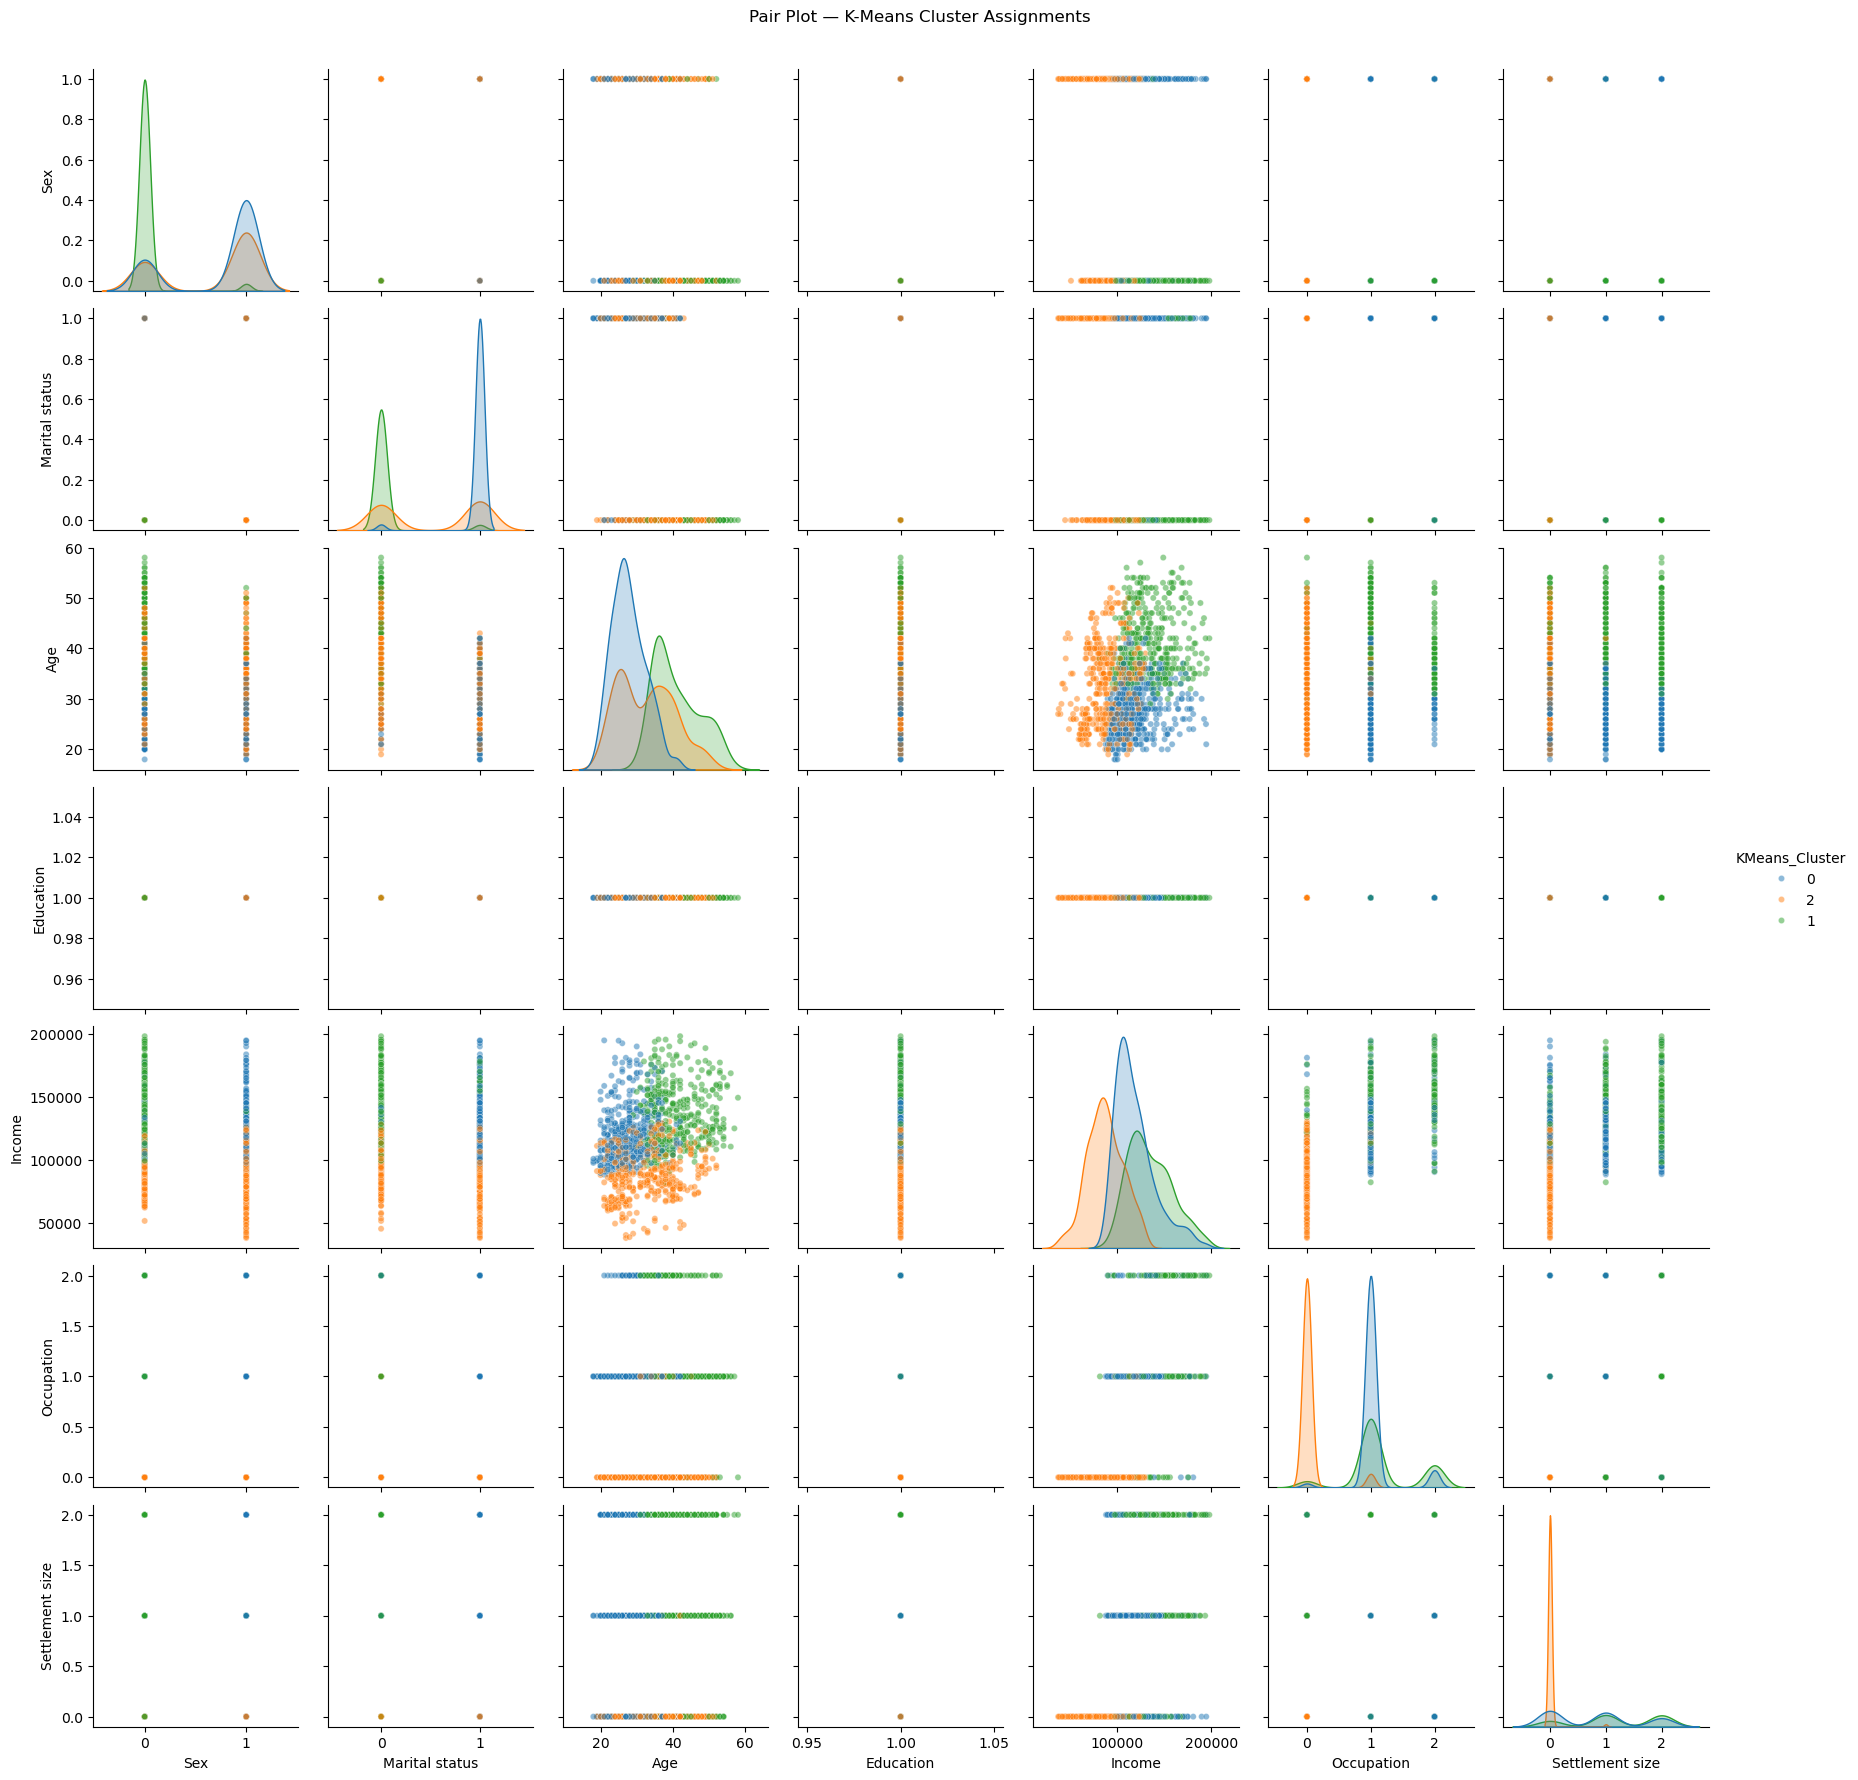

In [ ]:
# Pair plot across all features colored by K-Means cluster
plot_df = df_clean.drop(columns=["Agg_Cluster"]).copy()
plot_df["KMeans_Cluster"] = plot_df["KMeans_Cluster"].astype(str)

sns.pairplot(
    plot_df, hue="KMeans_Cluster",
    palette="tab10", plot_kws={"alpha": 0.5, "s": 20}
)
plt.suptitle("Pair Plot — K-Means Cluster Assignments", y=1.02)
plt.show()

### Silhoutte Plot

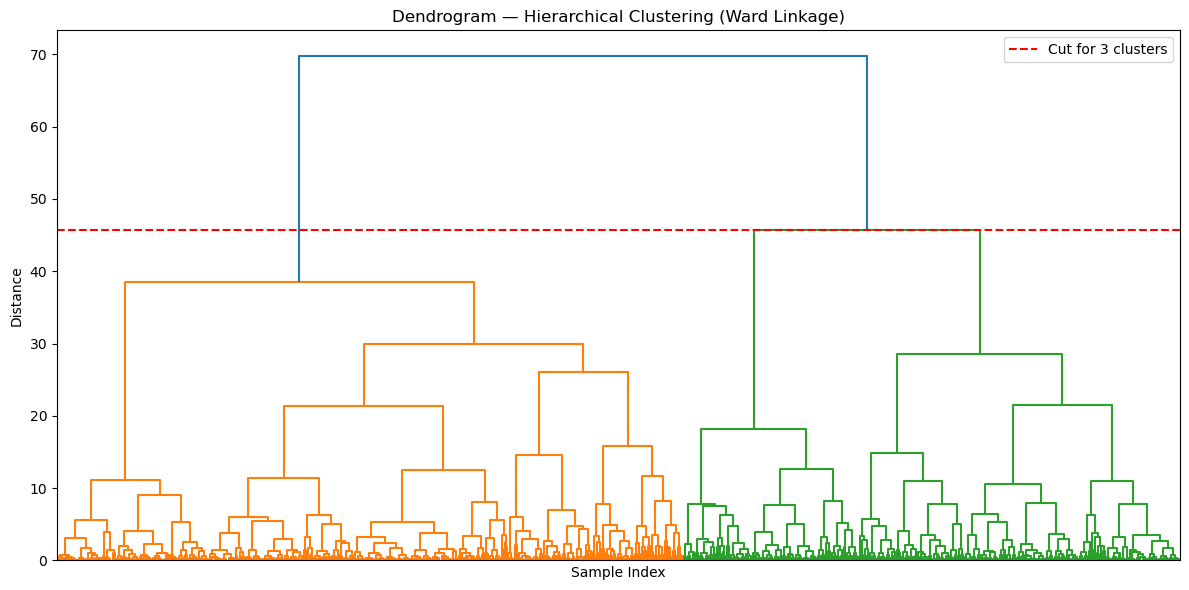

In [ ]:
# Create linkage matrix for dendrogram
linkage_matrix = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, no_labels=True)
plt.title('Dendrogram — Hierarchical Clustering ')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.axhline(y=linkage_matrix[-optimal_k+1, 2],
            c='red', linestyle='--',
            label=f'Cut for {optimal_k} clusters')
plt.legend()
plt.tight_layout()
plt.show()


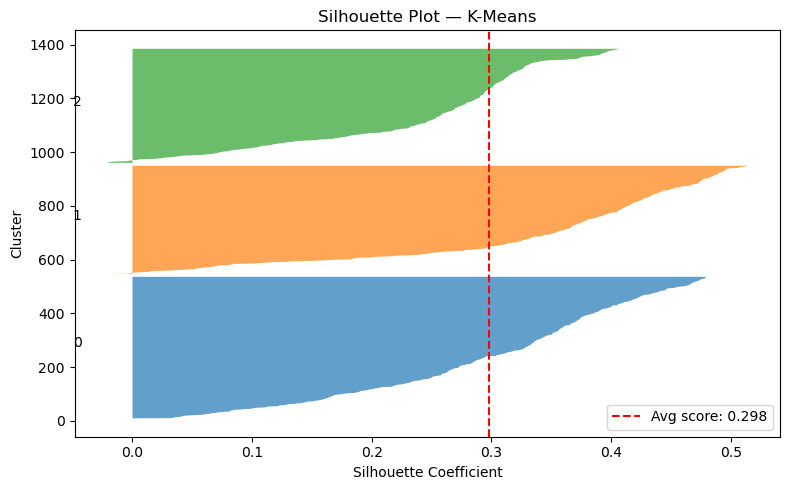

In [ ]:
# Per-sample silhouette coefficients for K-Means
labels = df_clean["KMeans_Cluster"].values
sil_vals = silhouette_samples(X, labels)
avg_score = sil_vals.mean()

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10

for i in range(optimal_k):
    cluster_vals = np.sort(sil_vals[labels == i])
    size = cluster_vals.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(
        np.arange(y_lower, y_upper), 0, cluster_vals, alpha=0.7
    )
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

ax.axvline(
    x=avg_score, color="red", linestyle="--",
    label=f"Avg score: {avg_score:.3f}"
)
ax.set_title("Silhouette Plot — K-Means")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.legend()
plt.tight_layout()
plt.show()

### Overall Analysis

*How well did K-Means and Hierarchical Clustering segment the data?*


Both models produced clear segments between  Income and Age, but K-Means forming more geometrically even clusters and Hierarchical Clustering had more dense clusters that seemed to have closer data points. The overall structure was similar between both methods.

*What challenges did you encounter in feature scaling and outlier detection?*

The main challenge was that most features were boolean values translated or had 2-4 options, so outlier detection didn't really exist for a lot of the colums


*How do silhouette and Davies-Bouldin scores help in cluster evaluation?*


Silhouette scores measure how similar each point is to its own cluster compared to neighboring clusters — a score closer to 1 means well-separated clusters, closer to 0 means overlapping.